# Imports

In [1]:
import sys
sys.path.append('../src')

import pymongo
import pandas as pd
from load_to_mongodb import db
import matplotlib.pyplot as plt
import seaborn as sns

import os

os.makedirs("results", exist_ok=True)

In [2]:
# Print to see if db was well imported from "load_to_mongodb.py"
print(db.movies_collection.count_documents({}))

1478


# MongoDB Query

## Q1 Query

In [3]:
pipeline_q1 = [
    {
        "$match": {
            "trailer.genre": {
                "$in": ["Action", "Comedy"]
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "genre": "$trailer.genre",
            "favorability": "$trailer.favorability",
            "averageRating": "$ratings.averageRating"
        }
    }
]

q1_result = db.movies_collection.aggregate(pipeline_q1)
list(q1_result)[:5]

[{'genre': 'Action', 'favorability': 0.6518987341772152, 'averageRating': 5.7},
 {'genre': 'Action', 'favorability': 0.631578947368421, 'averageRating': 7.7},
 {'genre': 'Comedy', 'favorability': 0.6506024096385542, 'averageRating': 5.1},
 {'genre': 'Action', 'favorability': 0.5481481481481482, 'averageRating': 5.3},
 {'genre': 'Comedy', 'favorability': 0.6, 'averageRating': 5.8}]

## Q2 Query

In [4]:
pipeline_q2 = [
    {
        "$match": {
            "$or": [
                {
                    "ratings.averageRating": {
                        "$gte": 7
                    }
                },
                {
                    "ratings.averageRating": {
                        "$lte": 4
                    }
                }
            ]
        }
    },
    {
        "$addFields": {
            "rating_group": {
                "$cond": [
                    {
                        "$gte": ["$ratings.averageRating", 7]
                    },
                    "high rating",
                    "low rating"
                ]
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "primaryTitle": 1,
            "averageRating": "$ratings.averageRating",
            "favorability": "$trailer.favorability",
            "rating_group": 1
        }
    },
    {
        "$sort": {
            "rating_group": 1
        }
    }
]

q2_result = db.movies_collection.aggregate(pipeline_q2)

list(q2_result)[:5]

[{'primaryTitle': 'Corpse Bride',
  'rating_group': 'high rating',
  'averageRating': 7.4,
  'favorability': 0.695364238410596},
 {'primaryTitle': 'Star Wars: Episode III - Revenge of the Sith',
  'rating_group': 'high rating',
  'averageRating': 7.7,
  'favorability': 0.631578947368421},
 {'primaryTitle': 'The Bank Job',
  'rating_group': 'high rating',
  'averageRating': 7.2,
  'favorability': 0.8070175438596491},
 {'primaryTitle': 'Children of Men',
  'rating_group': 'high rating',
  'averageRating': 7.9,
  'favorability': 0.6601307189542484},
 {'primaryTitle': "Before the Devil Knows You're Dead",
  'rating_group': 'high rating',
  'averageRating': 7.3,
  'favorability': 0.8}]

## Q3 Query

In [5]:
pipeline_q3 = [
    {
        "$match": {
            "trailer.rating": {"$in": ["R", "PG", "PG-13", "G"]}
        }
    },
    {
        "$addFields": {
            "rating_group": {
                "$cond": {
                    "if": {"$eq": ["$trailer.rating", "R"]},
                    "then": "R-Rated",
                    "else": "Non R-Rated"
                }
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "primaryTitle": 1,
            "rating": "$trailer.rating",
            "rating_group": 1,
            "averageRating": "$ratings.averageRating",
            "favorability": "$trailer.favorability"
        }
    },
    {
        "$sort": {
            "rating_group": 1,
            "averageRating": 1
        }
    }
]

q3_result = db.movies_collection.aggregate(pipeline_q3)
list(q3_result)[:5]


[{'primaryTitle': 'LOL',
  'rating_group': 'Non R-Rated',
  'rating': 'PG-13',
  'averageRating': 1.5,
  'favorability': 0.7987012987012987},
 {'primaryTitle': 'Disaster Movie',
  'rating_group': 'Non R-Rated',
  'rating': 'PG-13',
  'averageRating': 1.9,
  'favorability': 0.4034090909090909},
 {'primaryTitle': 'Into the Woods',
  'rating_group': 'Non R-Rated',
  'rating': 'PG',
  'averageRating': 2.1,
  'favorability': 0.6705202312138728},
 {'primaryTitle': 'Son of the Mask',
  'rating_group': 'Non R-Rated',
  'rating': 'PG',
  'averageRating': 2.3,
  'favorability': 0.5833333333333334},
 {'primaryTitle': 'Dragonball Evolution',
  'rating_group': 'Non R-Rated',
  'rating': 'PG',
  'averageRating': 2.5,
  'favorability': 0.6264367816091954}]

# Visualization

This section turns the MongoDB aggregation results into figures for three research questions (RQ1–RQ3). Each RQ uses **two** complementary views where it helps: one that emphasizes **aggregates** (means or counts) and one that shows **distributions** (box plots).

| Figure | Saved as | What it shows |
|--------|----------|----------------|
| RQ1 grouped bar | `results/mongodb_rq1_bar.png` | Mean trailer favorability vs mean IMDb rating by genre (Action vs Comedy); IMDb is divided by 10 for scale alignment. |
| RQ1 box plot | `results/mongodb_rq1_boxplot.png` | Distribution of **per-movie** IMDb ratings for Action vs Comedy. |
| RQ2 histogram | `results/mongodb_rq2_histogram.png` | How many movies fall in each favorability bin for **high** (≥7) vs **low** (≤4) IMDb groups. |
| RQ2 box plot | `results/mongodb_rq2_boxplot.png` | Distribution of trailer favorability for high vs low IMDb groups. |
| RQ3 bar | `results/mongodb_rq3_bar.png` | Mean trailer favorability for **R-rated** vs **non–R-rated** MPAA groups (with seaborn uncertainty bars). |


## Q1 Visualization

**Research question:** Compare trailer **favorability** and IMDb **averageRating** between **Action** and **Comedy** titles in the MongoDB `movies` collection.

The next code cell produces a **grouped bar chart** of genre-level means; the following code cell is a **box plot** of raw IMDb ratings to show spread within each genre.


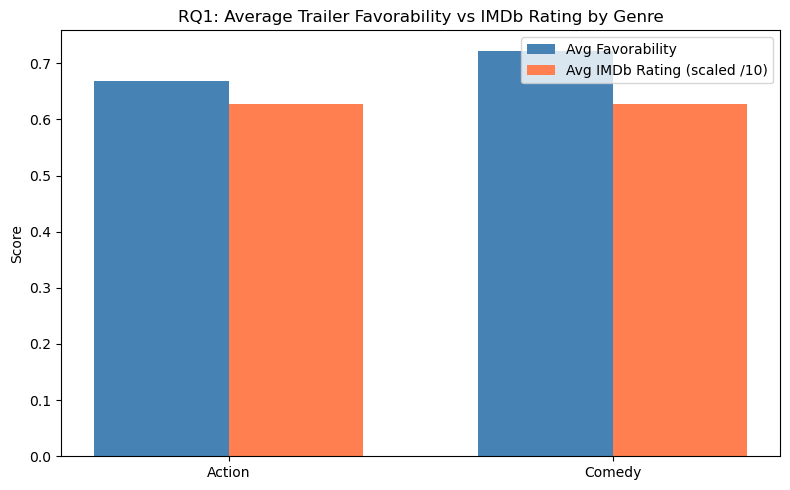

RQ1 plot saved.


In [ ]:
# Note: Phase 3 used scatter plots with trend lines (Q1, Q2)
# and box plots (Q3). Phase 4 uses different chart types
# to provide new perspectives on the same data.

# --- Visualization 1: Genre Analysis ---
# Grouped bar chart of average favorability and average IMDb
# rating per genre. Phase 3 used scatter plots with trend lines.

q1_result = list(db.movies_collection.aggregate(pipeline_q1))
q1_df = pd.DataFrame(q1_result)

q1_summary = q1_df.groupby('genre').agg(
    avg_favorability=('favorability', 'mean'),
    avg_imdb=('averageRating', 'mean')
).reset_index()

x = range(len(q1_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width/2 for i in x], q1_summary['avg_favorability'],
       width, label='Avg Favorability', color='steelblue')
ax.bar([i + width/2 for i in x], q1_summary['avg_imdb'] / 10,
       width, label='Avg IMDb Rating (scaled /10)', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(q1_summary['genre'])
ax.set_ylabel("Score")
ax.set_title("RQ1: Average Trailer Favorability vs IMDb Rating by Genre")
ax.legend()
plt.tight_layout()
plt.savefig("results/mongodb_rq1_bar.png", dpi=150)
plt.show()
print("RQ1 plot saved.")

### RQ1 — Grouped bar chart

**What to read:** For each genre there are two bars: **mean trailer favorability** (0–1) and **mean IMDb rating ÷ 10** so it is comparable on a similar scale to favorability.

**Why it matters:** You can see whether Action vs Comedy differ in *average* audience reaction on YouTube vs *average* critic/audience IMDb score. **Caveat:** Means hide variation; use the next box plot for IMDb spread.


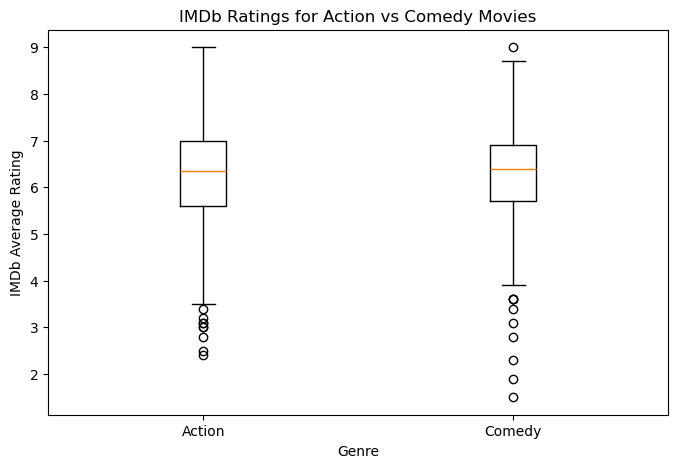

In [ ]:
q1_result = list(db.movies_collection.aggregate(pipeline_q1))
df_q1 = pd.DataFrame(q1_result)

plt.figure(figsize=(8, 5))
plt.boxplot([
    df_q1[df_q1["genre"] == "Action"]["averageRating"],
    df_q1[df_q1["genre"] == "Comedy"]["averageRating"]
])

plt.xticks([1, 2], ["Action", "Comedy"])
plt.xlabel("Genre")
plt.ylabel("IMDb Average Rating")
plt.title("IMDb Ratings for Action vs Comedy Movies")
plt.savefig("results/mongodb_rq1_boxplot.png", dpi=150)

plt.show()

### RQ1 — Box plot of IMDb ratings

**What to read:** Each box is the distribution of **per-document** `averageRating` for that genre: median (line inside the box), quartiles (box), whiskers, and outliers.

**Why it matters:** Compare **central tendency** and **dispersion** between Action and Comedy. A higher median or a tighter box means different things than a simple mean from the bar chart.


## Q2 Visualization

**Research question:** Do **trailer favorability** distributions differ between movies with **high** vs **low** IMDb `averageRating` (≥ 7 vs ≤ 4)?

The next cell is an **overlapping histogram**; the following cell is a **box plot** of the same favorability split by group.


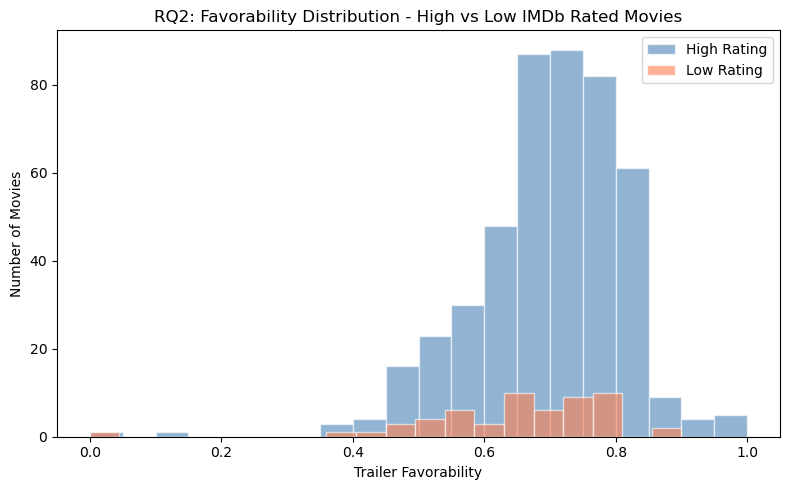

RQ2 plot saved.


In [8]:
# --- Visualization 2: High vs Low Rated Movies ---
# Overlapping histogram showing favorability distribution
# for high vs low rated movies. Phase 3 used scatter plots.

q2_result = list(db.movies_collection.aggregate(pipeline_q2))
q2_df = pd.DataFrame(q2_result)

fig, ax = plt.subplots(figsize=(8, 5))
for group, color in [("high rating", "steelblue"), ("low rating", "coral")]:
    subset = q2_df[q2_df['rating_group'] == group]['favorability']
    ax.hist(subset, bins=20, alpha=0.6, label=group.title(),
            color=color, edgecolor='white')
ax.set_xlabel("Trailer Favorability")
ax.set_ylabel("Number of Movies")
ax.set_title("RQ2: Favorability Distribution - High vs Low IMDb Rated Movies")
ax.legend()
plt.tight_layout()
plt.savefig("./results/mongodb_rq2_histogram.png", dpi=150)
plt.show()
print("RQ2 plot saved.")

### RQ2 — Overlapping histograms

**What to read:** Films are split into **high** IMDb (≥ 7) and **low** (≤ 4). For each group, the plot counts movies in bins of **trailer favorability** (overlapping colors).

**Why it matters:** You see whether one group’s favorability distribution is shifted (e.g., higher overall) or wider than the other. The y-axis is **count of movies**, not density.


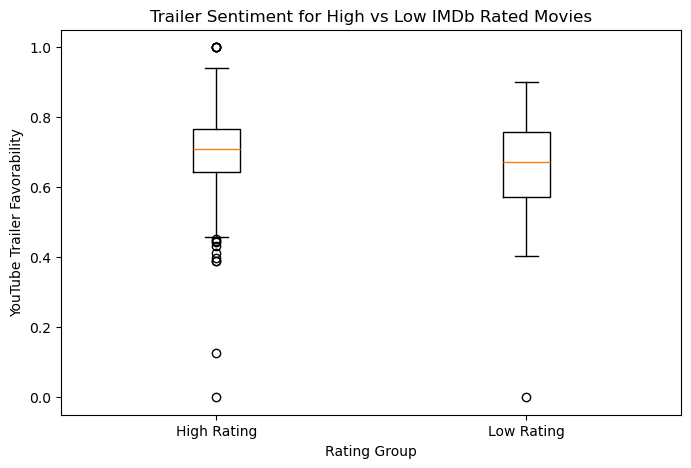

In [9]:
q2_result = list(db.movies_collection.aggregate(pipeline_q2))
df_q2 = pd.DataFrame(q2_result)

plt.figure(figsize=(8, 5))
plt.boxplot([
    df_q2[df_q2["rating_group"] == "high rating"]["favorability"],
    df_q2[df_q2["rating_group"] == "low rating"]["favorability"]
])

plt.xticks([1, 2], ["High Rating", "Low Rating"])
plt.xlabel("Rating Group")
plt.ylabel("YouTube Trailer Favorability")
plt.title("Trailer Sentiment for High vs Low IMDb Rated Movies")
plt.savefig("./results/mongodb_rq2_boxplot.png", dpi=150)
plt.show()

### RQ2 — Box plot of trailer favorability

**What to read:** Compare **trailer favorability** between high- and low-IMDb groups using medians, quartiles, and outliers in one view.

**Why it matters:** This pairs with the histogram: the histogram shows **shape and modality**; the box plot summarizes **robust location and spread** for group comparison.


## Q3 Visualization

**Research question:** Compare **mean trailer favorability** between **R-rated** and **non–R-rated** films (MPAA buckets from the aggregation pipeline).

The following cell plots a **bar chart** with seaborn.


/var/folders/sb/wp21_1l15kq0mgvtyzvc97s40000gq/T/ipykernel_21804/3623052378.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q3_df, x='rating_group', y='favorability',


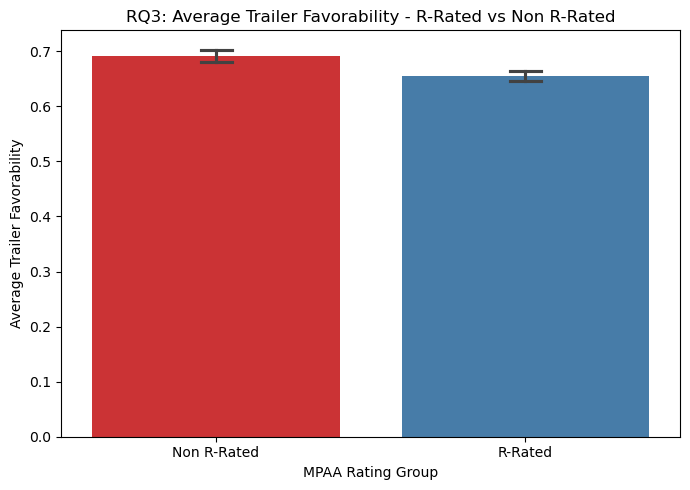

RQ3 plot saved.


In [ ]:
# --- Visualization 3: R-Rated vs Non R-Rated ---
# Bar chart comparing average favorability between
# R-Rated and Non R-Rated movies. Phase 3 used box plots.

q3_result = list(db.movies_collection.aggregate(pipeline_q3))
q3_df = pd.DataFrame(q3_result)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=q3_df, x='rating_group', y='favorability',
            palette='Set1', capsize=0.1, ax=ax)
ax.set_xlabel("MPAA Rating Group")
ax.set_ylabel("Average Trailer Favorability")
ax.set_title("RQ3: Average Trailer Favorability - R-Rated vs Non R-Rated")
plt.tight_layout()
plt.savefig("./results/mongodb_rq3_bar.png", dpi=150)
plt.show()
print("RQ3 plot saved.")

### RQ3 — Bar chart (mean favorability by MPAA group)

**What to read:** `seaborn.barplot` plots **mean** `favorability` for each `rating_group` (R-rated vs non–R-rated). Error bars reflect uncertainty around those means (implementation depends on seaborn version).

**Why it matters:** It answers whether average trailer sentiment differs between content-rating buckets at the **aggregate** level. This is not per-film inference; interpret as a comparison of group means.
